# Limpieza de texto — subset de 3000 imágenes (Modelo 1)

EasyOCR + inpaint TELEA para texto quemado, y HoughCircles para el marcador
de lateralidad. Misma lógica que en `dataset_prueba`, ahora aplicada sobre
`3000imagenes` y guardando en una carpeta paralela con la misma estructura.

Orden correcto: limpieza de texto a resolución completa (el crop pulmonar
va después, en otro paso).

In [1]:
import cv2
import numpy as np
import easyocr

reader = easyocr.Reader(['en'], gpu=True)

def eliminar_texto(image_path, umbral_confianza=0.6):
    img = cv2.imread(image_path)
    resultado = reader.readtext(image_path, detail=1)

    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    for (bbox, texto, confianza) in resultado:
        if confianza > umbral_confianza:
            pts = np.array(bbox, dtype=np.int32)
            # Pequeño margen para cubrir bordes del texto
            cv2.fillPoly(mask, [pts], 255)

    # TELEA es mejor para texturas continuas como tejido pulmonar
    img_limpia = cv2.inpaint(img, mask, inpaintRadius=7, flags=cv2.INPAINT_TELEA)
    return img_limpia

In [2]:
def remove_laterality_circle(image: np.ndarray,
                              search_top_fraction: float = 0.20,
                              dp: float = 1.2,
                              min_dist: int = 30,
                              param1: int = 50,
                              param2: int = 45,
                              min_radius: int = 15,
                              max_radius: int = 40,
                              verbose: bool = True) -> np.ndarray:
    result = image.copy()
    h, w = image.shape[:2]
    search_h = int(h * search_top_fraction)
    roi = image[:search_h, :]

    if roi.dtype != np.uint8:
        roi_8 = cv2.normalize(roi, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        roi_8 = roi.copy()

    roi_gray = cv2.cvtColor(roi_8, cv2.COLOR_BGR2GRAY) if roi_8.ndim == 3 else roi_8
    roi_blurred = cv2.GaussianBlur(roi_gray, (5, 5), 1)

    circles = cv2.HoughCircles(
        roi_blurred, cv2.HOUGH_GRADIENT,
        dp=dp, minDist=min_dist,
        param1=param1, param2=param2,
        minRadius=min_radius, maxRadius=max_radius
    )

    n_circulos = 0
    if circles is not None:
        circles = np.round(circles[0, :]).astype(int)
        n_circulos = len(circles)
        if verbose:
            print(f"  Círculos detectados: {n_circulos}")

        for (cx, cy, r) in circles:
            mask = np.zeros((search_h, w), dtype=np.uint8)
            cv2.circle(mask, (cx, cy), r + 3, 255, -1)

            # Mismo inpaint suave que eliminar_texto
            roi_inpainted = cv2.inpaint(
                result[:search_h], mask,
                inpaintRadius=7, flags=cv2.INPAINT_TELEA
            )
            result[:search_h] = roi_inpainted
            if verbose:
                print(f"    Círculo ({cx},{cy}) r={r} → inpaint TELEA")
    else:
        if verbose:
            print("  No se detectaron círculos")

    return result, n_circulos

In [3]:
def limpiar_imagen(image_path, umbral_confianza=0.6, verbose=False):
    # Paso 1: EasyOCR para texto
    img = eliminar_texto(image_path, umbral_confianza=umbral_confianza)

    # Paso 2: HoughCircles para marcador de lateralidad
    img, n_circulos = remove_laterality_circle(img, verbose=verbose)

    return img, n_circulos

## Verificación en una imagen antes del batch

Revisa el antes/después sobre una imagen del set de 3000 antes de lanzar
las 3000 (validar el componente antes de avanzar).

Imagen de prueba: C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\3000imagenes\files\p10\p10002428\s54020701\40a4d537-de28a3ab-aa746c28-750aea7d-2965bcdb.jpg
  No se detectaron círculos


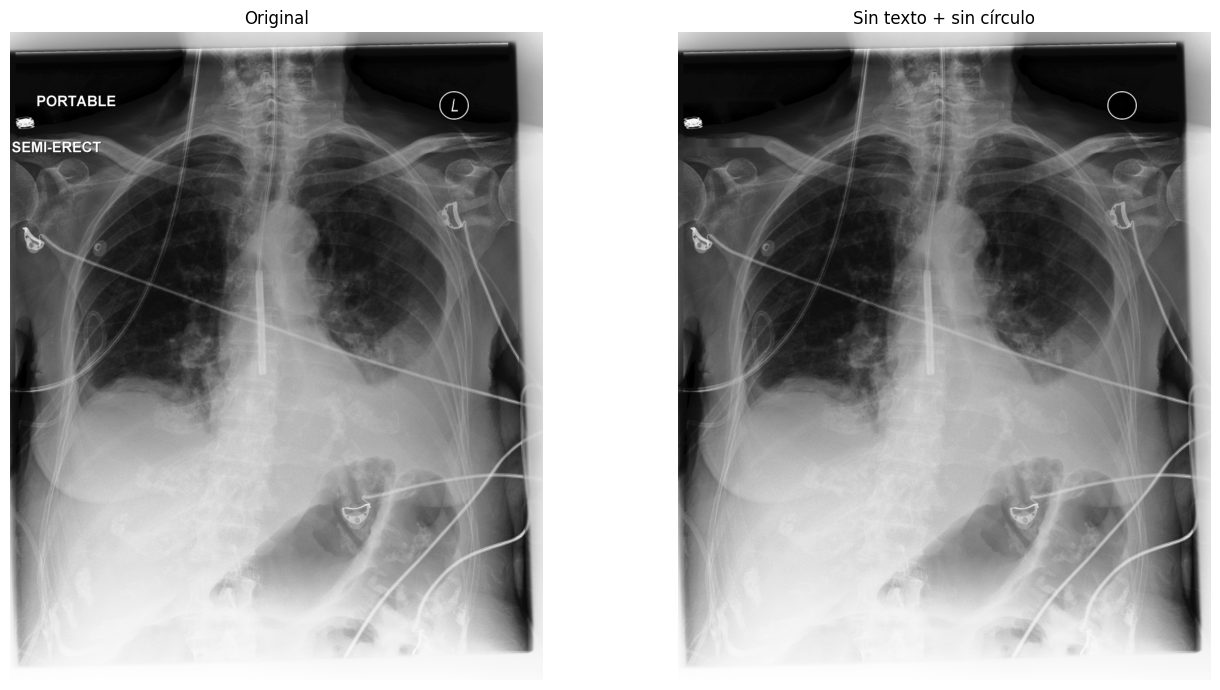

In [6]:
import os
import matplotlib.pyplot as plt

PROYECTO_ROOT = r'C:\Users\trodr\Documents\proyecto-torax-v2.0'
INPUT_ROOT = os.path.join(PROYECTO_ROOT, '01-dataset', 'dataset-completo-merge', '3000imagenes')

# Tomar la primera imagen que encuentre en 3000imagenes
sample_path = None
for root, dirs, files in os.walk(INPUT_ROOT):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_path = os.path.join(root, f)
            break
    if sample_path:
        break

print("Imagen de prueba:", sample_path)

img_original = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
img_limpia, _ = limpiar_imagen(sample_path, umbral_confianza=0.6, verbose=True)
img_limpia_rgb = cv2.cvtColor(img_limpia, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_original, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_limpia_rgb, cmap='gray'); axes[1].set_title('Sin texto + sin círculo'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Limpiar las 3000 imágenes y guardarlas

Recorre `3000imagenes`, limpia cada imagen y la guarda en
`3000imagenes-limpieza-texto` con la **misma estructura de carpetas**.
Es reanudable: si ya existe el archivo de salida, lo salta.

In [ ]:
import os
from tqdm import tqdm

# ------------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------------
PROYECTO_ROOT = r'C:\Users\trodr\Documents\proyecto-torax-v2.0'

INPUT_ROOT  = os.path.join(PROYECTO_ROOT, '01-dataset', 'dataset-completo-merge', '3000imagenes')
OUTPUT_ROOT = os.path.join(PROYECTO_ROOT, '01-dataset', 'dataset-completo-merge', '3000imagenes-limpieza-texto')

UMBRAL_CONFIANZA = 0.6   # afinado para reducir falsos positivos de EasyOCR (antes 0.3)

# ------------------------------------------------------------------
# RECOLECTAR IMÁGENES







for img_path in tqdm(imagenes, desc="Limpiando"):
    rel_path = os.path.relpath(img_path, INPUT_ROOT)
    output_path = os.path.join(OUTPUT_ROOT, rel_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Reanudable: si ya está limpia, saltar
    if os.path.exists(output_path):
        saltadas += 1
        continue

    try:
        img_limpia, n_circulos = limpiar_imagen(
            img_path, umbral_confianza=UMBRAL_CONFIANZA, verbose=False
        )
        if img_limpia is not None:
            cv2.imwrite(output_path, img_limpia)
            total_circulos += n_circulos
            procesadas += 1
        else:
            errores.append((img_path, "No se pudo leer"))
    except Exception as e:
        errores.append((img_path, str(e)))

print(f"\nProcesadas en esta corrida: {procesadas}")
print(f"Ya existían (saltadas):     {saltadas}")
print(f"Círculos eliminados (total): {total_circulos}")
print(f"Errores: {len(errores)}")
for path, err in errores[:20]:
    print(f"  {path}: {err}")

Total imágenes encontradas: 2994


Limpiando: 100%|██████████| 2994/2994 [12:40:42<00:00, 15.24s/it]  


Procesadas en esta corrida: 2994
Ya existían (saltadas):     0
Círculos eliminados (total): 2610
Errores: 0
